In [18]:
from tensorflow import keras
from keras import layers
from keras.models import Sequential
from keras.layers import Dense, Dropout
import numpy as np
from hoda_loader import load_hoda
import matplotlib.pyplot as plt

In [19]:
X_train, y_train, X_test, y_test = load_hoda(training_sample_size=3500, test_sample_size=400, size=28)

In [20]:
# Pre-process input data
''' normalize our data values to the range [0, 1] '''
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255

In [21]:
# Reshape to original image shape (n x 784) ==> (n x 28 x 28 x 1)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [22]:
# Pre-process class labels
y_train = keras.utils.to_categorical(y_train)
y_test = keras.utils.to_categorical(y_test)

In [23]:
# Define model architecture
model = Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(layers.Dense(10, activation='softmax'))

C:\Users\aydin\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
# Compile model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [25]:
# Fit model on training data
history = model.fit(X_train, y_train, epochs=200, batch_size=256, validation_split=0.2)

Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/step - accuracy: 0.2782 - loss: 2.1383 - val_accuracy: 0.6143 - val_loss: 1.7391
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.5118 - loss: 1.4804 - val_accuracy: 0.7771 - val_loss: 0.8479
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - accuracy: 0.6482 - loss: 0.9929 - val_accuracy: 0.8300 - val_loss: 0.5527
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 0.7521 - loss: 0.7424 - val_accuracy: 0.8571 - val_loss: 0.4298
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.7968 - loss: 0.6028 - val_accuracy: 0.8943 - val_loss: 0.3250
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.8368 - loss: 0.4950 - val_accuracy: 0.9043 - val_loss: 0.2775
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 170ms/step - accuracy: 0.8468 - loss: 0.4591 - val_accuracy: 0.9143 - val_loss: 0.2468
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 156ms/step - accuracy: 0.8764 - loss: 0.3688 - val_accu

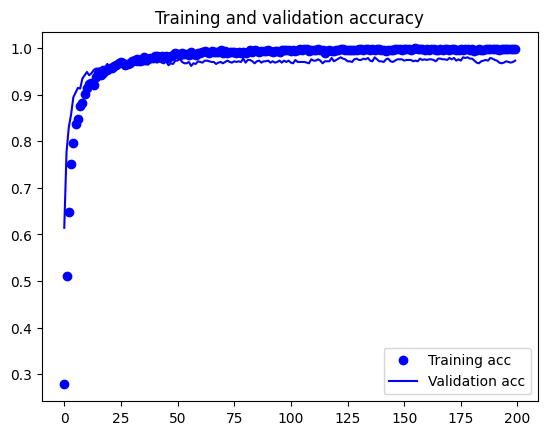

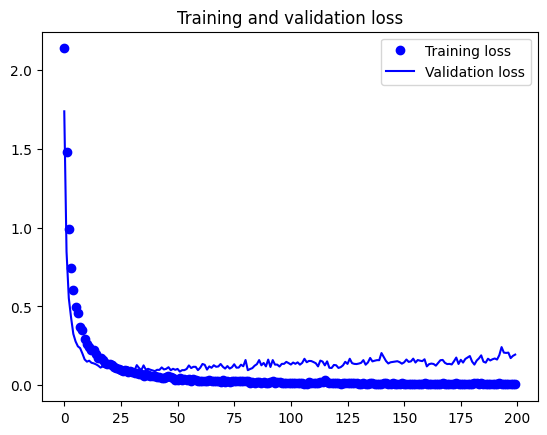

In [28]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()